# **Networkx exercises - Day 1**

Complete the notebook and upload it to moodle until the next lesson. Apart from the code, please include a written answer if necessary.
Before you upload the notebook, make sure that you **restart the kernel** and **rerun the whole notebook** from start to finish and save it.

For the exercises you will have to look up the appropriate functions in the [networkx documentation](https://networkx.org/documentation/stable/index.html).

In [1]:
import numpy as np
import networkx as nx

In [2]:
# Load a given adjacency matrix from file
file_name = "AdjacencyMatrix.txt"
adjacency_matrix = np.loadtxt(file_name)

# Generate the network from the adjacency matrix
my_network = nx.from_numpy_array(adjacency_matrix)

In [3]:
my_network

In [4]:
# access nodes
my_network.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76))

In [5]:
# Count the number of nodes and edges in the network 
no_edges = len(my_network.edges) 
no_nodes = len(my_network.nodes) 
print(f"The network has {no_nodes} nodes and {no_edges} edges.")

The network has 77 nodes and 254 edges.


In [6]:
# is the network directed?
my_network.is_directed()

False

In [7]:
# By default networkx maps the node names/number to their degree as an iterator over (node, degree) pairs.
# Sometime it is easier to work with these mapping in form of a dictionary
degree_mapping = my_network.degree()
degree_mapping

DegreeView({0: 1, 1: 10, 2: 3, 3: 3, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 36, 11: 1, 12: 2, 13: 1, 14: 1, 15: 1, 16: 7, 17: 9, 18: 7, 19: 7, 20: 7, 21: 7, 22: 7, 23: 15, 24: 11, 25: 16, 26: 11, 27: 17, 28: 4, 29: 8, 30: 2, 31: 4, 32: 1, 33: 2, 34: 6, 35: 6, 36: 6, 37: 6, 38: 6, 39: 3, 40: 1, 41: 11, 42: 3, 43: 3, 44: 2, 45: 1, 46: 2, 47: 1, 48: 22, 49: 7, 50: 2, 51: 7, 52: 2, 53: 1, 54: 4, 55: 19, 56: 2, 57: 11, 58: 15, 59: 11, 60: 9, 61: 11, 62: 13, 63: 12, 64: 13, 65: 12, 66: 10, 67: 1, 68: 10, 69: 10, 70: 10, 71: 9, 72: 3, 73: 2, 74: 2, 75: 7, 76: 7})

In [8]:
# we convert it to dictionary because it is easier to work with it (e.g. access keys and values)
degree_dictionary = dict(degree_mapping)

### Exercise 1
Draw the network that we imported earlier and stored as ``my network``.
Optional: customize node colors, transparency, experiment with layouts...

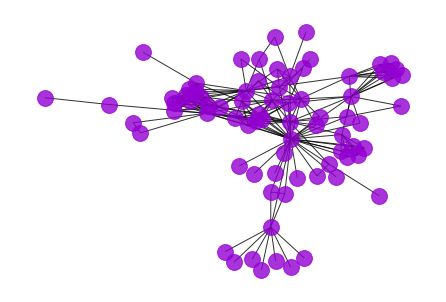

In [9]:
positions = nx.spring_layout(my_network, seed = 2)
# positions = nx.spiral_layout(my_network)
# positions = nx.random_layout(my_network, seed = 0)
nx.draw(my_network, alpha = 0.8, node_color = "darkviolet", node_size = 250, pos = positions) 

### Exercise 2
Use the `count_nonzero` function in `numpy` to count the total number of ones in the `adjacency_matrix`. What does this tell you about the network?


In [10]:
np.count_nonzero(adjacency_matrix)/2

254.0

### Exercise 3
Calculate the diameter and the average shortest path length of the network . What does this tell you about the network?

In [11]:
nx.diameter(my_network)

5

In [12]:
nx.average_shortest_path_length(my_network)

2.6411483253588517

### Exercise 4
Find the shortest path from node 8 to node 16 in the network. Is this longer or shorter than the average shortest path?

In [13]:
shortest_path_length = nx.shortest_path_length(my_network, 8, 16)
shortest_path_length

4

In [14]:
# another way
shortest_path = nx.shortest_path(my_network, 8, 16)
shortest_path

[8, 1, 10, 23, 16]

In [16]:
shortest_path_length2 = len(shortest_path) - 1 # Note that path length is the number of edges and not the nodes
shortest_path_length2

4

In [17]:
shortest_path_length > nx.average_shortest_path_length(my_network)

True

### Exercise 5
Is the network connected?

In [19]:
nx.is_connected(my_network)

True

### Exercise 6
Use the information from the `adjacency_matrix` to calculate the average degree, k, of the network.

In [21]:
# count nonzero elements, divide by number of nodes
np.count_nonzero(adjacency_matrix)/adjacency_matrix.shape[0]

6.597402597402597

In [22]:
# another way - sum up all the columns to get degrees, then take the mean
np.mean(sum(adjacency_matrix))

6.597402597402597

In [23]:
adjacency_matrix.shape

(77, 77)

### Exercise 7
Now, use the `degree_dictionary` to calculate the average degree. 

In [24]:
np.mean(list(degree_dictionary.values()))

6.597402597402597

### Exercise 8
What is the degree of node 48? How does it compare to the average degree?

In [25]:
print(degree_dictionary[48])
print(my_network.degree(48)) # another method

22
22


### Exercise 9
Remove node 31 from the network and recalculate the average degree. What do you observe? 
Then remove node 10 from the original network and recalculate the average degree. What do you observe? 

In [26]:
# make a copy of the old network before you remove nodes
my_network2 = my_network.copy()

In [27]:
my_network2.remove_node(31)
degree_mapping2 = my_network2.degree()
degree_dictionary2 = dict(degree_mapping2)
np.mean(list(degree_dictionary2.values()))

6.578947368421052

In [28]:
my_network3 = my_network.copy()
my_network3.remove_node(10)
degree_mapping3 = my_network3.degree()
degree_dictionary3 = dict(degree_mapping3)
np.mean(list(degree_dictionary3.values()))

5.7368421052631575

### Exercise 10
Why is the effect of removal is so different for the two nodes? Go back to the original network and check how the nodes differ.

In [29]:
print("The degree of node 10 is", my_network.degree()[10])
print("The degree of node 31 is", my_network.degree()[31])


The degree of node 10 is 36
The degree of node 31 is 4


### Bonus exercise (optional)
Use the adjacency matrix to calculate the number of paths of lengths 1-10 from node 8 to node 16. What do you observe and why do you think that is?

In [30]:
max_path_length = 10
for i in range(1, max_path_length+1):
    print(f"{int(np.linalg.matrix_power(adjacency_matrix, i)[8,16])} paths with length: {i}")

0 paths with length: 1
0 paths with length: 2
0 paths with length: 3
1 paths with length: 4
16 paths with length: 5
226 paths with length: 6
2690 paths with length: 7
31258 paths with length: 8
352225 paths with length: 9
3973678 paths with length: 10


The path number increases very fast. This is because with this approach, paths can have repeated nodes (e.g. A-B-A-C).

Use networkx function ```all_simple_paths``` to calculate the number of simple paths (no repeated nodes) of lengths 1-10 from node 8 to node 16.
Note that path length is the number of edges, not the number of nodes.

How does it work? It uses **depth-first search** algorithm.

* Start at the source node
* Explore neighbors recursively (DFS)
* Keep a current path list
* If you reach the target, yield that path
* Backtrack and try other possibilities
* Never revisit nodes already in the current path

Intuitively, it tries every possible route from A to B without ever revisiting a node.

In [31]:
# initiate empty dictionary where we will store the numbers as {path length: number of paths}
paths = {}
for i in range(max_path_length+1):
    paths[i] = 0
    
# calculate all simple paths shorter or equal to 'max_path_length'
for path in nx.all_simple_paths(my_network, 8, 16, cutoff=max_path_length):
    
    # add the path to the corresponding path length in the dictionary
    # we subtract one because len(path) is the number of nodes, and there are one less edges than nodes
    paths[(len(path)-1)] += 1

In [32]:
paths

{0: 0,
 1: 0,
 2: 0,
 3: 0,
 4: 1,
 5: 16,
 6: 161,
 7: 1316,
 8: 9662,
 9: 68053,
 10: 478936}

In [33]:
# another way
lengths = []
for path in nx.all_simple_paths(my_network, 8, 16, cutoff=max_path_length):
    
    # add the path to the corresponding path length in the dictionary
    # we subtract one because len(path) is the number of nodes, and there are one less edges than nodes
    lengths.append(len(path)-1)

In [34]:
counts = {}

for x in lengths:
    if x in counts:
        counts[x] += 1
    else:
        counts[x] = 1
counts

{7: 1316, 8: 9662, 9: 68053, 10: 478936, 6: 161, 5: 16, 4: 1}